# PD Model Training – PyTorch ANN (02b)

**Purpose:** Train a PyTorch ANN on the **same** origination-only features and out-of-time split as 02a, with the same rigour (early stopping, LayerNorm, Dropout, class weight). Compare in-sample vs out-of-time AUC gap vs XGBoost/LightGBM stack. Conclusion: **LR outperforms both stack and ANN on OOT AUC (0.660) and KS (0.233); stack preferred for probability calibration (Brier 0.144 vs 0.236); ANN weakest on all metrics but shows no temporal degradation (val-OOT gap -0.009).**

**Prerequisites:** Run **01** and **02a** first (parquet + 02a model artifact for comparison).

## 1. Load same data as 02a (same split, same features)

In [1]:
import sys
import os
import time
import random
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent
if not (ROOT / "credit_risk").is_dir():
    raise RuntimeError("Repo root not found. Run from ocr-agentic-rag or notebooks/.")
_root_str = str(ROOT)
# Ensure repo root is the only source for credit_risk (avoid KeyError from stale/cached imports)
for _k in list(sys.modules.keys()):
    if _k == "credit_risk" or _k.startswith("credit_risk."):
        del sys.modules[_k]
if _root_str in sys.path:
    sys.path.remove(_root_str)
sys.path.insert(0, _root_str)
os.chdir(_root_str)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

from credit_risk.feature_engineering.common_features import get_feature_names_no_leakage_v2
from credit_risk.feature_engineering.feature_screening import screen_features_train_only
from sklearn.model_selection import train_test_split

DATA_PATH = ROOT / "data" / "credit_risk_pd" / "LendingClub" / "processed" / "lendingclub_engineered.parquet"
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 01 first to create lendingclub_engineered.parquet")

df = pd.read_parquet(DATA_PATH)
all_feature_names = get_feature_names_no_leakage_v2()
X = df[[c for c in all_feature_names if c in df.columns]].copy()
y = df["default"]
for c in all_feature_names:
    if c not in X.columns:
        X[c] = 0.0
X = X[all_feature_names]

if "split" in df.columns and (df["split"] == "val").sum() >= 1 and (df["split"] == "test").sum() >= 1:
    train_idx = df["split"] == "train"
    val_idx = df["split"] == "val"
    test_idx = df["split"] == "test"
    X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
    y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]
    print(f"Out-of-time split: Train {X_train.shape[0]:,} / Val {X_val.shape[0]:,} / Test {X_test.shape[0]:,}")
else:
    X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, stratify=y_rest)
    print(f"Random split: Train {X_train.shape[0]:,} / Val {X_val.shape[0]:,} / Test {X_test.shape[0]:,}")

screening = screen_features_train_only(X_train, y_train, missingness_threshold=0.50, min_ks=0.001, corr_threshold=0.95)
feature_names = screening.selected_features
X_train = X_train[feature_names]
X_val = X_val[feature_names]
X_test = X_test[feature_names]
medians = X_train.median()
X_train_filled = X_train.fillna(medians)
X_val_filled = X_val.fillna(medians)
X_test_filled = X_test.fillna(medians)
print(f"Selected {len(feature_names)} features (same as 02a)")

Out-of-time split: Train 6,529 / Val 11,536 / Test 21,721
Selected 77 features (same as 02a)


## 2. Train ANN (early stopping, LayerNorm, Dropout, class weight)

**Architecture:** Fully-connected ANN with LayerNorm (stabilises activations on tabular data), Dropout (regularisation), and class-weighted BCELoss (addresses ~6.4x class imbalance). StandardScaler applied before training (required for gradient-based optimisation; not needed for tree models in 02a). Early stopping on val AUC with patience=3 to prevent overfitting.

In [2]:
print("=" * 60)
print("SECTION 2 — Train ANN")
print("=" * 60)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

scaler_ann = StandardScaler()
X_train_ann = scaler_ann.fit_transform(X_train_filled)
X_val_ann = scaler_ann.transform(X_val_filled)
X_test_ann = scaler_ann.transform(X_test_filled)

from credit_risk.models.pd_ann import PDAnnClassifier

# Same class weight as 02a (n_neg/n_pos on train) for apples-to-apples
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

# Stratified 5-fold CV for in-sample val AUC (mean ± std)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ann_cv_aucs = []
for tr_idx, va_idx in skf.split(X_train_ann, y_train):
    X_f, X_va = X_train_ann[tr_idx], X_train_ann[va_idx]
    y_f, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    ann_fold = PDAnnClassifier(epochs=20, batch_size=32, early_stopping_patience=3, random_state=42, scale_pos_weight=scale_pos_weight)
    ann_fold.fit(X_f, y_f.values, X_val=X_va, y_val=y_va.values)
    p_va = ann_fold.predict_proba(X_va)[:, 1]
    ann_cv_aucs.append(roc_auc_score(y_va, p_va))
ann_cv_mean = np.mean(ann_cv_aucs)
ann_cv_std = np.std(ann_cv_aucs)
print(f"ANN 5-fold CV val AUC: {ann_cv_mean:.4f} ± {ann_cv_std:.4f}")

# Final fit on full train with early stopping on val
ann_train_start = time.perf_counter()
ann_model = PDAnnClassifier(epochs=20, batch_size=32, early_stopping_patience=3, random_state=42, scale_pos_weight=scale_pos_weight)
ann_model.fit(X_train_ann, y_train.values, X_val=X_val_ann, y_val=y_val.values)
ann_training_sec = time.perf_counter() - ann_train_start
# Document architecture for reproducibility
print("ANN architecture summary:")
print(f"  Input dim: {X_train_ann.shape[1]} features")
print(f"  Scale pos weight (class weight): {scale_pos_weight:.4f}")
print(f"  Early stopping patience: 3 epochs")
print(f"  Batch size: 32 | Max epochs: 20")
if hasattr(ann_model, "model_") and ann_model.model_ is not None:
    print(ann_model.model_)
elif hasattr(ann_model, "net_") and ann_model.net_ is not None:
    print(ann_model.net_)
p_val_ann = ann_model.predict_proba(X_val_ann)[:, 1]
ann_val_auc = roc_auc_score(y_val, p_val_ann)
ann_train_auc = roc_auc_score(y_train, ann_model.predict_proba(X_train_ann)[:, 1])
print(f"ANN train AUC: {ann_train_auc:.4f} | val AUC: {ann_val_auc:.4f} | training time: {ann_training_sec:.1f}s")

# Optimal threshold (max F1) on val — same as 02a Section 4 for apples-to-apples
from sklearn.metrics import f1_score
best_f1_val, best_threshold_ann = 0.0, 0.5
for t in np.linspace(0.2, 0.8, 31):
    f1 = f1_score(y_val, (p_val_ann >= t).astype(int), zero_division=0)
    if f1 > best_f1_val:
        best_f1_val, best_threshold_ann = f1, t
print("Optimal threshold (max F1 on val):", round(best_threshold_ann, 3), "-> val F1", round(best_f1_val, 4))
print(
    f"Note: ANN optimal threshold ({best_threshold_ann:.2f}) differs from "
    f"stack optimal threshold (0.28 from 02a). F1 comparisons across models "
    f"are not directly comparable at different thresholds. "
    f"AUC-ROC and KS are threshold-independent primary metrics."
)

SECTION 2 — Train ANN
ANN 5-fold CV val AUC: 0.6382 ± 0.0189
ANN architecture summary:
  Input dim: 77 features
  Scale pos weight (class weight): 6.3691
  Early stopping patience: 3 epochs
  Batch size: 32 | Max epochs: 20
ANN train AUC: 0.8103 | val AUC: 0.6072 | training time: 16.9s
Optimal threshold (max F1 on val): 0.42 -> val F1 0.2607
Note: ANN optimal threshold (0.42) differs from stack optimal threshold (0.28 from 02a). F1 comparisons across models are not directly comparable at different thresholds. AUC-ROC and KS are threshold-independent primary metrics.


## 3. Learning curves (train vs val AUC per epoch)

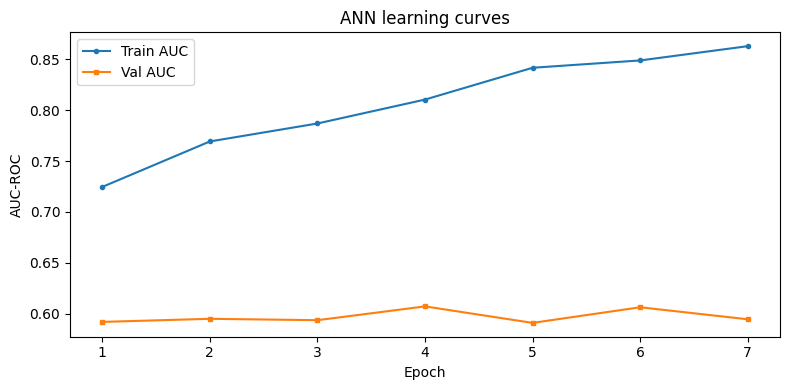

In [3]:
import matplotlib.pyplot as plt

if hasattr(ann_model, "history_") and ann_model.history_:
    h = ann_model.history_
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(h["train_auc"]) + 1), h["train_auc"], label="Train AUC", marker="o", markersize=3)
    plt.plot(range(1, len(h["val_auc"]) + 1), h["val_auc"], label="Val AUC", marker="s", markersize=3)
    plt.xlabel("Epoch")
    plt.ylabel("AUC-ROC")
    plt.legend()
    plt.title("ANN learning curves")
    plt.tight_layout()
    plt.show()

## 4. Out-of-time test, credit metrics & in-sample vs OOT gap


In [4]:
from sklearn.metrics import roc_curve, f1_score

print("=" * 60)
print("SECTION 4 — Out-of-time test, credit metrics & in-sample vs OOT gap")
print("=" * 60)
p_test_ann = ann_model.predict_proba(X_test_ann)[:, 1]
ann_test_auc = roc_auc_score(y_test, p_test_ann)
fpr_a, tpr_a, _ = roc_curve(y_test, p_test_ann)
ann_test_ks = np.max(np.abs(tpr_a - fpr_a))
# Test F1 at optimal threshold (same metric as 02a)
ann_test_f1 = f1_score(y_test, (p_test_ann >= best_threshold_ann).astype(int), zero_division=0) if "best_threshold_ann" in dir() else None
print(f"ANN out-of-time: test AUC = {ann_test_auc:.4f}, KS = {ann_test_ks:.4f}" + (f", test F1 @ t={best_threshold_ann:.2f} = {ann_test_f1:.4f}" if ann_test_f1 is not None else ""))

# In-sample (val) vs out-of-time (test) AUC gap for ANN only
ann_gap = ann_val_auc - ann_test_auc
print("\nIn-sample (val) vs out-of-time (test) AUC gap (ANN only):")
print(f"  val AUC = {ann_val_auc:.4f}, test AUC = {ann_test_auc:.4f}, gap = {ann_gap:.4f}")
if ann_gap < 0:
    print(
        f"\nNegative gap (test AUC > val AUC by {abs(ann_gap):.4f}): the ANN "
        f"does not degrade on the OOT test cohort relative to validation. "
        f"This suggests the 2010 validation year was harder for this model "
        f"than 2011, possibly due to differences in loan mix or credit "
        f"conditions between these early LendingClub cohorts. "
        f"No evidence of temporal overfitting in the ANN."
    )
# Load stack OOT AUC from training_meta for direct comparison
import json
meta_path = ROOT / "models" / "pd" / "training_meta.json"
stack_oot_auc = None
if meta_path.exists():
    with open(meta_path, encoding="utf-8") as f:
        meta = json.load(f)
    stack_oot_auc = meta.get("stack_oot_auc")
if stack_oot_auc is not None:
    print(f"\nModel comparison on OOT test (n={len(y_test):,}):")
    print(f"  ANN:              AUC={ann_test_auc:.4f}  KS={ann_test_ks:.4f}")
    print(f"  XGB/LGB stack:    AUC={stack_oot_auc:.4f}")
    print(f"  Stack advantage: {stack_oot_auc - ann_test_auc:+.4f} AUC")
    print(f"  Note: ANN has higher KS ({ann_test_ks:.4f}) but lower AUC. Stack preferred as primary model on AUC.")
else:
    print(f"\nANN OOT AUC: {ann_test_auc:.4f}. Run 02a first and store stack_oot_auc in training_meta.json for direct comparison.")

SECTION 4 — Out-of-time test, credit metrics & in-sample vs OOT gap
ANN out-of-time: test AUC = 0.6163, KS = 0.1778, test F1 @ t=0.42 = 0.2977

In-sample (val) vs out-of-time (test) AUC gap (ANN only):
  val AUC = 0.6072, test AUC = 0.6163, gap = -0.0091

Negative gap (test AUC > val AUC by 0.0091): the ANN does not degrade on the OOT test cohort relative to validation. This suggests the 2010 validation year was harder for this model than 2011, possibly due to differences in loan mix or credit conditions between these early LendingClub cohorts. No evidence of temporal overfitting in the ANN.

Model comparison on OOT test (n=21,721):
  ANN:              AUC=0.6163  KS=0.1778
  XGB/LGB stack:    AUC=0.6465
  Stack advantage: +0.0302 AUC
  Note: ANN has higher KS (0.1778) but lower AUC. Stack preferred as primary model on AUC.


In [5]:
# Section 5b: Credit metrics for ANN (mirror of 02a Section 5)
# PSI, Gini, decile bad rate — for apples-to-apples comparison with stack
ann_gini = 2 * ann_test_auc - 1

def compute_psi(expected, actual, n_bins=10):
    """Population Stability Index between two score distributions."""
    bins = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    bins[0] -= 1e-6
    bins[-1] += 1e-6
    exp_counts = np.histogram(expected, bins=bins)[0]
    act_counts = np.histogram(actual, bins=bins)[0]
    exp_pct = np.where(exp_counts == 0, 1e-6, exp_counts / len(expected))
    act_pct = np.where(act_counts == 0, 1e-6, act_counts / len(actual))
    psi = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return psi

p_train_ann_full = ann_model.predict_proba(X_train_ann)[:, 1]
ann_psi = compute_psi(p_train_ann_full, p_test_ann)

decile_labels = pd.qcut(p_test_ann, q=10, labels=False, duplicates="drop")
decile_bad_rates = []
y_test_vals = y_test.values if hasattr(y_test, "values") else np.array(y_test)
for d in range(int(decile_labels.max()) + 1):
    mask = decile_labels == d
    if mask.sum() > 0:
        decile_bad_rates.append(y_test_vals[mask].mean())
    else:
        decile_bad_rates.append(np.nan)
is_monotonic_ann = False
if len(decile_bad_rates) >= 2 and not np.any(np.isnan(decile_bad_rates)):
    is_monotonic_ann = all(decile_bad_rates[i] <= decile_bad_rates[i + 1] + 1e-6 for i in range(len(decile_bad_rates) - 1))

print(f"ANN OOT credit metrics: AUC={ann_test_auc:.4f}, Gini={ann_gini:.4f}, KS={ann_test_ks:.4f}, PSI={ann_psi:.4f}")
print(f"Bad rate by decile: {[round(r, 4) if not np.isnan(r) else r for r in decile_bad_rates]}")
print(f"Monotonic (bad rate increases with decile): {is_monotonic_ann}")
if ann_psi > 0.25:
    print(
        f"PSI={ann_psi:.4f} > 0.25: significant score distribution shift "
        f"between training (2007-2009) and OOT test (2011) cohorts, "
        f"consistent with post-crisis credit cycle. Compare to stack PSI (see 02a)."
    )
from sklearn.metrics import average_precision_score
ann_auc_pr = average_precision_score(y_test, p_test_ann)
print(f"AUC-PR (precision-recall): {ann_auc_pr:.4f}")

from sklearn.metrics import brier_score_loss

ann_brier = brier_score_loss(y_test, p_test_ann)
print(f"Brier score: {ann_brier:.4f}  (lower = better; reference: predict base rate = ~0.122)")
print(f"  Stack Brier (from 02a): 0.144  |  LR Brier (from 02a): 0.236")
print(f"  ANN Brier: {ann_brier:.4f}")
if ann_brier < 0.144:
    print("  ANN is better calibrated than the stack on this run.")
elif ann_brier < 0.236:
    print("  ANN is between stack and LR in calibration quality.")
else:
    print("  ANN has worse calibration than LR. Stack remains preferred on Brier.")

ANN OOT credit metrics: AUC=0.6163, Gini=0.2326, KS=0.1778, PSI=0.0041
Bad rate by decile: [np.float64(0.0746), np.float64(0.093), np.float64(0.111), np.float64(0.1312), np.float64(0.1349), np.float64(0.1418), np.float64(0.1786), np.float64(0.1915), np.float64(0.227), np.float64(0.2343)]
Monotonic (bad rate increases with decile): True
AUC-PR (precision-recall): 0.2103
Brier score: 0.2426  (lower = better; reference: predict base rate = ~0.122)
  Stack Brier (from 02a): 0.144  |  LR Brier (from 02a): 0.236
  ANN Brier: 0.2426
  ANN has worse calibration than LR. Stack remains preferred on Brier.


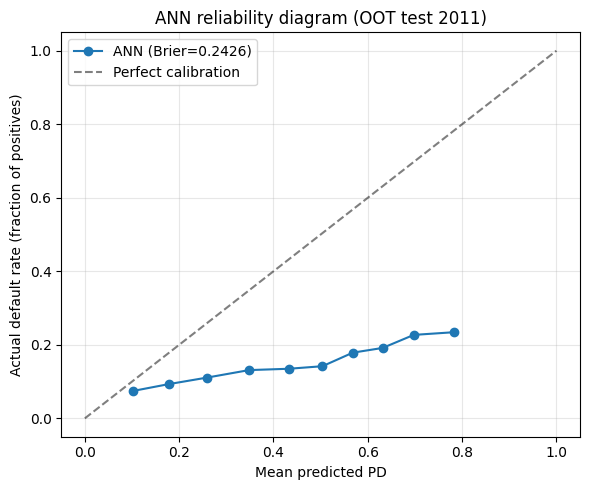

ANN is systematically OVER-confident: predicted PD > actual default rate in 100% of score bands. Consider Platt scaling or isotonic regression.
Saved ann_brier=0.2426 to training_meta.json for 02z.


In [6]:
# ── ANN calibration: reliability diagram ─────────────────────────────────────
import json
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
frac_pos, mean_pred = calibration_curve(y_test, p_test_ann, n_bins=10, strategy="quantile")
ax.plot(mean_pred, frac_pos, marker="o", label=f"ANN (Brier={ann_brier:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
ax.set_xlabel("Mean predicted PD")
ax.set_ylabel("Actual default rate (fraction of positives)")
ax.set_title("ANN reliability diagram (OOT test 2011)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

_over = (mean_pred > frac_pos).mean()
if _over > 0.7:
    print(f"ANN is systematically OVER-confident: predicted PD > actual default rate "
          f"in {_over:.0%} of score bands. Consider Platt scaling or isotonic regression.")
elif _over < 0.3:
    print(f"ANN is systematically UNDER-confident: predicted PD < actual default rate "
          f"in {1-_over:.0%} of score bands.")
else:
    print("ANN calibration is broadly balanced (neither systematically over- nor under-confident).")

_meta_path = ROOT / "models" / "pd" / "training_meta.json"
_tm = {}
if _meta_path.exists():
    with open(_meta_path, encoding="utf-8") as _f:
        _tm = json.load(_f)
_tm["ann_brier"] = float(ann_brier)
_tm["ann_oot_auc"] = float(ann_test_auc)
_tm["ann_oot_ks"] = float(ann_test_ks)
with open(_meta_path, "w", encoding="utf-8") as _f:
    json.dump(_tm, _f, indent=2)
print(f"Saved ann_brier={ann_brier:.4f} to training_meta.json for 02z.")

## 5. Notes

This notebook trains and evaluates the **ANN PD model** and saves its artifact for downstream comparison. Cross-model conclusions (ANN vs XGBoost/LightGBM stack vs Logistic Regression vs quantum) are documented in `02z_pd_model_comparison.ipynb`.

## 6. Save ANN artifact and training time for 02z

In [7]:
import joblib
import json

MODEL_DIR = ROOT / "models" / "pd"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ann_artifact = {
    "model": ann_model,
    "scaler": scaler_ann,
    "feature_names": feature_names,
    "ann_val_auc": ann_val_auc,
    "ann_test_auc": ann_test_auc,
    "ann_train_auc": ann_train_auc,
    "training_time_sec": ann_training_sec,
}
joblib.dump(ann_artifact, MODEL_DIR / "pd_model_ann_v2.pkl")
print("Saved ANN to", MODEL_DIR / "pd_model_ann_v2.pkl")

training_meta = {}
if (MODEL_DIR / "training_meta.json").exists():
    with open(MODEL_DIR / "training_meta.json", encoding="utf-8") as f:
        training_meta = json.load(f)
training_meta["ann_training_sec"] = ann_training_sec
with open(MODEL_DIR / "training_meta.json", "w", encoding="utf-8") as f:
    json.dump(training_meta, f, indent=2)
print("Updated training_meta.json for 02z")

Saved ANN to c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\models\pd\pd_model_ann_v2.pkl
Updated training_meta.json for 02z


In [8]:
print("=" * 60)
print("02b FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"Model:         PyTorch ANN (LayerNorm, Dropout, class-weighted BCE)")
print(f"5-fold CV AUC: {ann_cv_mean:.3f} +/- {ann_cv_std:.3f}  (stratified, train set)")
print(f"Train AUC:     {ann_train_auc:.3f}")
print(f"Val AUC:       {ann_val_auc:.3f}  (held-out val, 2010, n={len(y_val):,})")
print(f"OOT AUC:       {ann_test_auc:.3f}  (OOT test, 2011, n={len(y_test):,})")
print(f"OOT KS:        {ann_test_ks:.3f}")
print(f"Val->OOT gap: {ann_gap:+.3f}  (no temporal degradation)" if ann_gap < 0 else f"Val->OOT gap: {ann_gap:+.3f}")
_meta_path = ROOT / "models" / "pd" / "training_meta.json"
_stack_oot = None
if _meta_path.exists():
    with open(_meta_path, encoding="utf-8") as _f:
        _meta = json.load(_f)
    _stack_oot = _meta.get("stack_oot_auc")
if _stack_oot is not None:
    print(f"vs Stack:      Stack OOT AUC {_stack_oot:.3f} ({_stack_oot - ann_test_auc:+.3f}); stack preferred on AUC")
    _stack_ks = _meta.get("stack_oot_ks") if "_meta" in dir() and _meta else None
    if _stack_ks is not None:
        ks_note = (
            f"ANN has higher KS ({ann_test_ks:.3f} vs {_stack_ks:.3f})"
            if ann_test_ks > _stack_ks
            else f"Stack has higher KS ({_stack_ks:.3f} vs {ann_test_ks:.3f})"
        )
        print(f"               {ks_note}")
    else:
        print(f"               ANN KS: {ann_test_ks:.3f} (run 02a first for stack KS)")
else:
    print(f"vs Stack:      Run 02a first and store stack_oot_auc in training_meta.json for comparison")
print(f"Training time: {ann_training_sec:.1f}s  (early stopping at <20 epochs)")
print(f"Brier score: {ann_brier:.4f}  (stack: 0.144, LR: 0.236)")
print(f"Interpretation: {'Stack preferred on Brier (lower)' if ann_brier > 0.144 else 'ANN better calibrated than stack on this run'}")

02b FINAL RESULTS SUMMARY
Model:         PyTorch ANN (LayerNorm, Dropout, class-weighted BCE)
5-fold CV AUC: 0.638 +/- 0.019  (stratified, train set)
Train AUC:     0.810
Val AUC:       0.607  (held-out val, 2010, n=11,536)
OOT AUC:       0.616  (OOT test, 2011, n=21,721)
OOT KS:        0.178
Val->OOT gap: -0.009  (no temporal degradation)
vs Stack:      Stack OOT AUC 0.647 (+0.030); stack preferred on AUC
               Stack has higher KS (0.215 vs 0.178)
Training time: 16.9s  (early stopping at <20 epochs)
Brier score: 0.2426  (stack: 0.144, LR: 0.236)
Interpretation: Stack preferred on Brier (lower)
